## LangChain + Tavily联网搜索

In [1]:
import os

from langchain.chat_models import init_chat_model
from langchain_community.tools import TavilySearchResults
from langchain.schema import HumanMessage

### 1. Tavily联网搜索

In [2]:
# 先查看是否有TAVILY_API_KEY这个环境变量
len(os.environ["TAVILY_API_KEY"])

41

In [3]:
search = TavilySearchResults(max_results=2)
search

TavilySearchResults(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))

In [4]:
# 搜索测试一下
search.invoke("what is python")

[{'url': 'https://www.python.org/doc/essays/blurb/',
  'content': 'What is Python? Executive Summary | Python.org Python ▲ The Python Network Python Brochure Python Books Python Essays Python Conferences Python Logo Python Wiki Python News PSF News Python Events Python Events Archive What is Python? What is Python? Python is an interpreted, object-oriented, high-level programming language with dynamic semantics. Python supports modules and packages, which encourages program modularity and code reuse. Debugging Python programs is easy: a bug or bad input will never cause a segmentation fault. See also some comparisons between Python and other languages. The Python Software Foundation is the organization behind Python. Python Brochure Python Books Python Essays Python Conferences Python Logo Python Wiki Python News PSF News Python Events Python Events Archive python-dev list Python Software Foundation \xa0Legal Statements \xa0Privacy Notice'},
 {'url': 'https://aws.amazon.com/what-is/pyt

### 2. 本地知识库
> 这里以网页内容为例。
> ```pip install sentence-transformers```

In [5]:
os.environ["USER_AGENT"] = "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"

In [6]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain.chains import RetrievalQA
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [7]:
# 加载网页内容
loader = WebBaseLoader("https://langchain-ai.github.io/langgraph/")
docs = loader.load()
type(docs[0])

langchain_core.documents.base.Document

In [8]:
# 分割文本
documents = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100).split_documents(docs)
len(documents), type(documents[0])

(46, langchain_core.documents.base.Document)

In [9]:
# 生成嵌入向量并保存在FAISS向量数据库中
# vector = FAISS.from_documents(documents=documents, embedding=HuggingFaceBgeEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2"))
vector = FAISS.from_documents(documents=documents, embedding=HuggingFaceEmbeddings(model_name="BAAI/bge-large-en"))
retriever = vector.as_retriever()

In [10]:
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x3203d1950>, search_kwargs={})

In [11]:
retriever.invoke("Why use langgraph?")[0]

Document(id='dd2b615f-e34c-4847-9d77-eeedc62d91ad', metadata={'source': 'https://langchain-ai.github.io/langgraph/', 'title': 'Home', 'description': 'Build language agents as graphs', 'language': 'en'}, page_content='course, Introduction to LangGraph, available for free\nhere.\nLangGraph Platform¶')

现在我们将retriever封装为一个可以给智能体调用的工具。

**封装一个本地检索的工具**

In [12]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="langgraph search",
    description="Search for information about langgraph. For any question about langgraph, you must use this tool."
)

In [13]:
retriever_tool

Tool(name='langgraph search', description='Search for information about langgraph. For any question about langgraph, you must use this tool.', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x109fa3e20>, retriever=VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x3203d1950>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=functools.partial(<function _aget_relevant_documents at 0x10a1a2480>, retriever=VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x3203d1950>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={},

### 3. 大模型调用工具集
> 现在我们有了2个工具，联网搜索、本地文件资料检索工具。 接下来把这2个工具交给大模型使用。

In [14]:
# 工具集
tools = [search, retriever_tool]

In [15]:
# 实例化模型
model = init_chat_model(model="qwen2.5:7b", model_provider="ollama", base_url=os.environ["OLLAMA_API_BASE"])

In [16]:
# 简单调用
response = model.invoke([HumanMessage(content="Hi~I am alex.")])
response.content

'Hello Alex! Nice to meet you. How can I assist you today? Whether you have questions, need some information, or just want to chat about something, feel free to let me know.'

In [17]:
# 给模型绑定工具集
model_with_tools = model.bind_tools(tools)

**不调用工具的示例：**

In [18]:
resp01 = model_with_tools.invoke([HumanMessage(content="Hello.")])
print("resp.content:\t{}".format(resp01.content))
print("resp.tool_calls:\t{}".format(resp01.tool_calls))

resp.content:	Hello! How can I assist you today?
resp.tool_calls:	[]


**调用联网检索示例：**

In [19]:
resp02 = model_with_tools.invoke([HumanMessage(content="What's the wether in ShenZhen?")])
print("resp.content:\t{}".format(resp02.content))
print("resp.tool_calls:\t{}".format(resp02.tool_calls))

resp.content:	
resp.tool_calls:	[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in Shenzhen'}, 'id': '3d8a0743-8cd4-47ae-98d4-b67a13166ce2', 'type': 'tool_call'}]


> 到这里发现，模型只是知道了要调用工具，但是没有真正的调用。

接下来我们创建智能体来调用工具。

In [20]:
resp03 = model_with_tools.invoke([HumanMessage(content="What's langgraph?")])
print("resp.content:\t{}".format(resp03.content))
print("resp.tool_calls:\t{}".format(resp03.tool_calls))

resp.content:	
resp.tool_calls:	[{'name': 'langgraph search', 'args': {'query': "What's langgraph?"}, 'id': 'f6b8f96a-52ab-4479-b79b-dd1c6f308d28', 'type': 'tool_call'}]


### 4. 创建智能体

In [21]:
from langgraph.prebuilt import chat_agent_executor

In [22]:
# 创建智能体
agent_executor = chat_agent_executor.create_tool_calling_executor(model, tools)

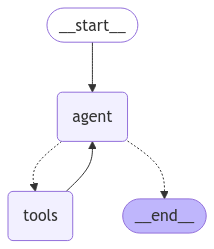

In [23]:
agent_executor

In [24]:
resp04 = agent_executor.invoke({"messages": [HumanMessage(content="Hello")]})
resp04["messages"][-1].content

'Hello! How can I assist you today?'

**调用联网搜索**

In [25]:
resp05 = agent_executor.invoke({"messages": [HumanMessage(content="What's the wether in ShenZhen?")]})
print("msg.content:\t{}".format(resp05["messages"][-1].content))
print("msg.tool_calls:\t{}".format(resp05["messages"][-1].tool_calls))

msg.content:	The current weather in Shenzhen, Guangdong, China is as follows:

- Temperature: 17.3°C (63.1°F)
- Last updated: March 05, 2025, at 10:30 AM local time.
- Weather Condition: Light rain

Other details include:
- Wind speed: 8.3 mph from the East
- Humidity: 83%
- Cloud cover: 75%

The visibility is good with 10 kilometers (6 miles), and there's a 50% chance of precipitation today. The UV index is at 1.3, which means it’s mild exposure to the sun.
msg.tool_calls:	[]


In [26]:
for item in resp05["messages"]:
    if hasattr(item, "tool_calls"):
        print("msg.tool_calls:\t{}".format(item.tool_calls))

msg.tool_calls:	[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Shenzhen'}, 'id': 'f60f1c67-bacd-4c9c-bae5-bb72cce7607c', 'type': 'tool_call'}]
msg.tool_calls:	[]


### 5. 给智能体添加记忆功能

In [27]:
from langgraph.checkpoint.memory import MemorySaver

In [28]:
memory = MemorySaver()

In [29]:
agent_executor_with_history = chat_agent_executor.create_tool_calling_executor(model, tools, checkpointer=memory)

In [30]:
config = {
    "configurable": {"thread_id": "123"}
}

for chunk in agent_executor_with_history.stream({
    "messages": HumanMessage(content="Hi~I am alex.")
}, config=config):
    print(chunk["agent"]["messages"][0].content)
    print("---")

Hello Alex! How can I assist you today?
---


In [31]:
for chunk in agent_executor_with_history.stream({
    "messages": HumanMessage(content="What is 101 * 102.")
}, config=config):
    print(chunk["agent"]["messages"][0].content)

The product of 101 and 102 is 10302.


In [32]:
for chunk in agent_executor_with_history.stream({
    "messages": HumanMessage(content="What is my name?")
}, config=config):
    print(chunk["agent"]["messages"][0].content)

You mentioned that your name is Alex. How can I assist you further, Alex?


In [33]:
for chunk in agent_executor_with_history.stream({
    "messages": HumanMessage(content="Why sky is blue?")
}, config=config):
    print(chunk["agent"]["messages"][0].content)

The sky appears blue because the Earth's atmosphere scatters shorter wavelength colors more than longer wavelength colors when sunlight passes through it. This phenomenon, known as Rayleigh scattering, makes the sky appear blue during clear daytime conditions. Would you like to know more about this or any other related topics?


In [34]:
for chunk in agent_executor_with_history.stream({
    "messages": HumanMessage(content="What is python?")
}, config=config):
    print(chunk["agent"]["messages"][0].content)

Python is a high-level, general-purpose programming language created by Guido van Rossum and first released in 1991. It is known for its readability and simplicity, making it an excellent choice for both beginners and experienced developers.

Here are some key features of Python:
- **Simplicity**: Python has a simple and easy-to-read syntax that emphasizes code readability.
- **Versatility**: It can be used for web development, data analysis, artificial intelligence, scientific computing, and more.
- **Large Standard Library**: Python comes with a vast standard library that supports many common programming tasks.
- **Interpreted Language**: Python is dynamically typed and interpreted, which means you don't need to compile your code before running it.

Would you like more detailed information on any specific aspect of Python?


In [35]:
for chunk in agent_executor_with_history.stream({
    "messages": HumanMessage(content="What's the wether in ShenZhen?")
}, config=config):
    if "agent" in chunk and "messages" in chunk["agent"]:
        print(chunk["agent"]["messages"][0].content)
    else:
        print(chunk)
        print("\n---\n")


{'tools': {'messages': [ToolMessage(content='[{"url": "https://www.weatherapi.com/", "content": "{\'location\': {\'name\': \'Shenzhen\', \'region\': \'Guangdong\', \'country\': \'China\', \'lat\': 22.5333, \'lon\': 114.1333, \'tz_id\': \'Asia/Hong_Kong\', \'localtime_epoch\': 1741140830, \'localtime\': \'2025-03-05 10:13\'}, \'current\': {\'last_updated_epoch\': 1741140000, \'last_updated\': \'2025-03-05 10:00\', \'temp_c\': 17.2, \'temp_f\': 63.0, \'is_day\': 1, \'condition\': {\'text\': \'Partly cloudy\', \'icon\': \'//cdn.weatherapi.com/weather/64x64/day/116.png\', \'code\': 1003}, \'wind_mph\': 8.3, \'wind_kph\': 13.3, \'wind_degree\': 94, \'wind_dir\': \'E\', \'pressure_mb\': 1014.0, \'pressure_in\': 29.94, \'precip_mm\': 0.02, \'precip_in\': 0.0, \'humidity\': 83, \'cloud\': 75, \'feelslike_c\': 17.2, \'feelslike_f\': 63.0, \'windchill_c\': 19.8, \'windchill_f\': 67.7, \'heatindex_c\': 19.8, \'heatindex_f\': 67.7, \'dewpoint_c\': 17.1, \'dewpoint_f\': 62.8, \'vis_km\': 10.0, \'v